## Week 3 - Manipulación de Datos con Python

### Filtrado, Agrupación y Merge de Datos

Crear datasets relacionados:

In [ ]:
import pandas as pd
import numpy as np

# Dataset de ventas
ventas = pd.DataFrame({
    'id_venta': range(1, 11),
    'id_cliente': np.random.choice([1, 2, 3, 4, 5], 10),
    'id_producto': np.random.choice([101, 102, 103, 104], 10),
    'cantidad': np.random.randint(1, 5, 10),
    'fecha': pd.date_range('2024-01-01', periods=10, freq='D')
})

# Dataset de clientes
clientes = pd.DataFrame({
    'id_cliente': [1, 2, 3, 4, 5],
    'nombre': ['Ana', 'Carlos', 'María', 'Juan', 'Luis'],
    'ciudad': ['Madrid', 'Barcelona', 'Madrid', 'Valencia', 'Sevilla']
})

# Dataset de productos
productos = pd.DataFrame({
    'id_producto': [101, 102, 103, 104],
    'nombre': ['Laptop', 'Mouse', 'Teclado', 'Monitor'],
    'precio': [1200, 25, 80, 300],
    'categoria': ['Electrónica', 'Accesorios', 'Accesorios', 'Electrónica']
})

print("Datasets creados:")
print(f"Ventas: {ventas.shape}")
print(f"Clientes: {clientes.shape}")
print(f"Productos: {productos.shape}")

Datasets creados:
Ventas: (10, 5)
Clientes: (5, 3)
Productos: (4, 4)


Filtrado avanzado con query():

In [ ]:
print(ventas.head(), "\n")
print(productos.head())

   id_venta  id_cliente  id_producto  cantidad      fecha
0         1           1          103         2 2024-01-01
1         2           3          102         3 2024-01-02
2         3           2          103         1 2024-01-03
3         4           1          103         3 2024-01-04
4         5           3          104         3 2024-01-05 

   id_producto   nombre  precio    categoria
0          101   Laptop    1200  Electrónica
1          102    Mouse      25   Accesorios
2          103  Teclado      80   Accesorios
3          104  Monitor     300  Electrónica


In [ ]:
# Ventas del mes actual con query
ventas_recientes = ventas.query('fecha >= "2024-01-05"')
print(f"\nVentas recientes: {len(ventas_recientes)}")

# Productos caros usando variable externa
precio_limite = 100
productos_caros = productos.query('precio >= @precio_limite')
print(f"Productos caros (>= {precio_limite}): {productos_caros['nombre'].tolist()}")


Ventas recientes: 6
Productos caros (>= 100): ['Laptop', 'Monitor']


Agrupación y agregación:

In [ ]:
print(ventas.head())

   id_venta  id_cliente  id_producto  cantidad      fecha
0         1           1          103         2 2024-01-01
1         2           3          102         3 2024-01-02
2         3           2          103         1 2024-01-03
3         4           1          103         3 2024-01-04
4         5           3          104         3 2024-01-05


In [ ]:
# Ventas por producto
ventas_por_producto = ventas.groupby('id_producto')['cantidad'].sum()
print(f"\nVentas por producto:\n{ventas_por_producto}")

# Estadísticas por cliente
stats_por_cliente = ventas.groupby('id_cliente').agg({
    'cantidad': ['sum', 'mean'],
    'id_venta': 'count'
})
print(f"\nEstadísticas por cliente:\n{stats_por_cliente}")


Ventas por producto:
id_producto
101    6
102    6
103    6
104    6
Name: cantidad, dtype: int64

Estadísticas por cliente:
           cantidad           id_venta
                sum      mean    count
id_cliente                            
1                 6  2.000000        3
2                 7  2.333333        3
3                 6  3.000000        2
4                 5  2.500000        2


Merge para análisis completo:

In [ ]:
# Unir ventas con productos
ventas_productos = pd.merge(ventas, productos, on='id_producto')

# Calcular totales
ventas_productos['total'] = ventas_productos['cantidad'] * ventas_productos['precio']

# Unir con clientes
#analisis_completo = pd.merge(ventas_productos, clientes, on='id_cliente')
analisis_completo = pd.merge(ventas_productos, clientes, on='id_cliente', suffixes=('_producto', '_cliente'))

print(f"\nAnálisis completo (primeras 5 filas):\n{analisis_completo.head()}")

# Análisis por ciudad
ventas_por_ciudad = analisis_completo.groupby('ciudad')['total'].sum()
print(f"\nVentas totales por ciudad:\n{ventas_por_ciudad}")


Análisis completo (primeras 5 filas):
   id_venta  id_cliente  id_producto  cantidad      fecha nombre_producto  \
0         1           1          103         2 2024-01-01         Teclado   
1         2           3          102         3 2024-01-02           Mouse   
2         3           2          103         1 2024-01-03         Teclado   
3         4           1          103         3 2024-01-04         Teclado   
4         5           3          104         3 2024-01-05         Monitor   

   precio    categoria  total nombre_cliente     ciudad  
0      80   Accesorios    160            Ana     Madrid  
1      25   Accesorios     75          María     Madrid  
2      80   Accesorios     80         Carlos  Barcelona  
3      80   Accesorios    240            Ana     Madrid  
4     300  Electrónica    900          María     Madrid  

Ventas totales por ciudad:
ciudad
Barcelona    7280
Madrid       1400
Valencia      950
Name: total, dtype: int64


In [ ]:
ventas_productos

,id_venta,id_cliente,id_producto,cantidad,fecha,nombre,precio,categoria,total
0,1,1,103,2,2024-01-01,Teclado,80,Accesorios,160
1,2,3,102,3,2024-01-02,Mouse,25,Accesorios,75
2,3,2,103,1,2024-01-03,Teclado,80,Accesorios,80
3,4,1,103,3,2024-01-04,Teclado,80,Accesorios,240
4,5,3,104,3,2024-01-05,Monitor,300,Electrónica,900
5,6,1,102,1,2024-01-06,Mouse,25,Accesorios,25
6,7,2,101,3,2024-01-07,Laptop,1200,Electrónica,3600
7,8,4,102,2,2024-01-08,Mouse,25,Accesorios,50
8,9,2,101,3,2024-01-09,Laptop,1200,Electrónica,3600
9,10,4,104,3,2024-01-10,Monitor,300,Electrónica,900


In [ ]:
analisis_completo

,id_venta,id_cliente,id_producto,cantidad,fecha,nombre_producto,precio,categoria,total,nombre_cliente,ciudad
0,1,1,103,2,2024-01-01,Teclado,80,Accesorios,160,Ana,Madrid
1,2,3,102,3,2024-01-02,Mouse,25,Accesorios,75,María,Madrid
2,3,2,103,1,2024-01-03,Teclado,80,Accesorios,80,Carlos,Barcelona
3,4,1,103,3,2024-01-04,Teclado,80,Accesorios,240,Ana,Madrid
4,5,3,104,3,2024-01-05,Monitor,300,Electrónica,900,María,Madrid
5,6,1,102,1,2024-01-06,Mouse,25,Accesorios,25,Ana,Madrid
6,7,2,101,3,2024-01-07,Laptop,1200,Electrónica,3600,Carlos,Barcelona
7,8,4,102,2,2024-01-08,Mouse,25,Accesorios,50,Juan,Valencia
8,9,2,101,3,2024-01-09,Laptop,1200,Electrónica,3600,Carlos,Barcelona
9,10,4,104,3,2024-01-10,Monitor,300,Electrónica,900,Juan,Valencia


Filtrado final:

In [ ]:
# Clientes con compras > 1000
clientes_top = analisis_completo.groupby(['id_cliente', 'nombre_cliente'])['total'].sum()
clientes_top = clientes_top[clientes_top > 1000]
print(f"\nClientes con compras > 1000:\n{clientes_top}")


Clientes con compras > 1000:
id_cliente  nombre_cliente
2           Carlos            7280
Name: total, dtype: int64


### Manejo de Datos Faltantes y Outliers

Crear dataset con problemas realistas:

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Crear dataset con missing values y outliers
np.random.seed(42)
n = 1000

datos = pd.DataFrame({
    'id': range(1, n+1),
    'edad': np.random.normal(35, 10, n).clip(18, 80),  # Normal con límites
    'salario': np.random.lognormal(10, 0.5, n),  # Distribución log-normal
    'horas_trabajo': np.random.normal(40, 5, n).clip(20, 60),
    'satisfaccion': np.random.randint(1, 6, n),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'HR'], n)
})

# Introducir missing values
mask_missing = np.random.random(n) < 0.1  # 10% missing
datos.loc[mask_missing, 'salario'] = np.nan

mask_missing_horas = np.random.random(n) < 0.05  # 5% missing
datos.loc[mask_missing_horas, 'horas_trabajo'] = np.nan

# Introducir outliers
outlier_indices = np.random.choice(n, 20, replace=False)
datos.loc[outlier_indices[:10], 'salario'] = datos.loc[outlier_indices[:10], 'salario'] * 10  # Salarios extremos altos
datos.loc[outlier_indices[10:], 'horas_trabajo'] = np.random.choice([80, 90, 100], 10)  # Horas imposibles

print(f"Dataset creado: {datos.shape}")
print(f"Valores faltantes por columna:\n{datos.isnull().sum()}")

Dataset creado: (1000, 6)
Valores faltantes por columna:
id                0
edad              0
salario          95
horas_trabajo    46
satisfaccion      0
departamento      0
dtype: int64


Analizar datos faltantes:

In [ ]:
# Análisis detallado de missing values
print("Porcentaje de datos faltantes:")
print((datos.isnull().sum() / len(datos) * 100).round(2))

# Patrón de missing values
import missingno as msno
# msno.matrix(datos)  # Visualización (requiere instalar missingno)

# Análisis por departamento
print("\nMissing values por departamento:")
print(datos.groupby('departamento').apply(lambda x: x.isnull().sum()))

Porcentaje de datos faltantes:
id               0.0
edad             0.0
salario          9.5
horas_trabajo    4.6
satisfaccion     0.0
departamento     0.0
dtype: float64

Missing values por departamento:
              id  edad  salario  horas_trabajo  satisfaccion  departamento
departamento                                                              
HR             0     0       20             13             0             0
IT             0     0       18              3             0             0
Marketing      0     0       23             17             0             0
Ventas         0     0       34             13             0             0


/tmp/ipython-input-3742569873.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(datos.groupby('departamento').apply(lambda x: x.isnull().sum()))


Imputación de valores faltantes:

In [ ]:
# Imputación por media para horas_trabajo
media_horas = datos['horas_trabajo'].mean()
datos['horas_trabajo'] = datos['horas_trabajo'].fillna(media_horas)

# Imputación por mediana para salario (más robusto a outliers)
mediana_salario = datos['salario'].median()
datos['salario'] = datos['salario'].fillna(mediana_salario)

# Verificar que no queden missing values
print(f"\nValores faltantes después de imputación: {datos.isnull().sum().sum()}")


Valores faltantes después de imputación: 0


Detección de outliers:

In [ ]:
# Función para detectar outliers usando IQR
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return (data[columna] < limite_inferior) | (data[columna] > limite_superior)

# Detectar outliers en salario y horas
outliers_salario = detectar_outliers_iqr(datos, 'salario')
outliers_horas = detectar_outliers_iqr(datos, 'horas_trabajo')

print(f"\nOutliers detectados:")
print(f"Salario: {outliers_salario.sum()} ({outliers_salario.mean()*100:.1f}%)")
print(f"Horas trabajo: {outliers_horas.sum()} ({outliers_horas.mean()*100:.1f}%)")


Outliers detectados:
Salario: 55 (5.5%)
Horas trabajo: 24 (2.4%)


Manejo de outliers:

In [ ]:
# Para horas_trabajo: cap at reasonable maximum
max_horas_normales = 60
datos.loc[datos['horas_trabajo'] > max_horas_normales, 'horas_trabajo'] = max_horas_normales

# Para salario: transformar usando log (más robusto)
datos['salario_log'] = np.log1p(datos['salario'])

# Comparar estadísticas antes y después
print(f"\nEstadísticas de salario original:")
print(datos['salario'].describe().round(2))

print(f"\nEstadísticas de salario transformado (log):")
print(datos['salario_log'].describe().round(2))

# Verificar reducción de outliers
outliers_salario_log = detectar_outliers_iqr(datos, 'salario_log')
print(f"\nOutliers en salario log-transformado: {outliers_salario_log.sum()}")


Estadísticas de salario original:
count      1000.00
mean      28034.05
std       31587.51
min        5063.46
25%       17302.19
50%       22873.10
75%       30819.42
max      518367.29
Name: salario, dtype: float64

Estadísticas de salario transformado (log):
count    1000.00
mean       10.06
std         0.53
min         8.53
25%         9.76
50%        10.04
75%        10.34
max        13.16
Name: salario_log, dtype: float64

Outliers en salario log-transformado: 29


Visualización de distribuciones:

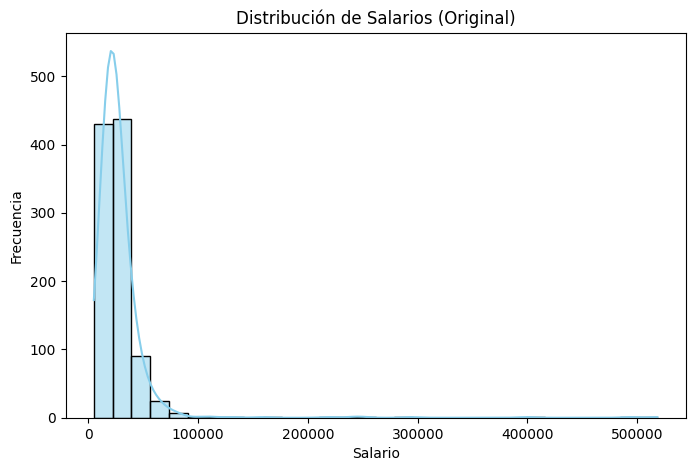

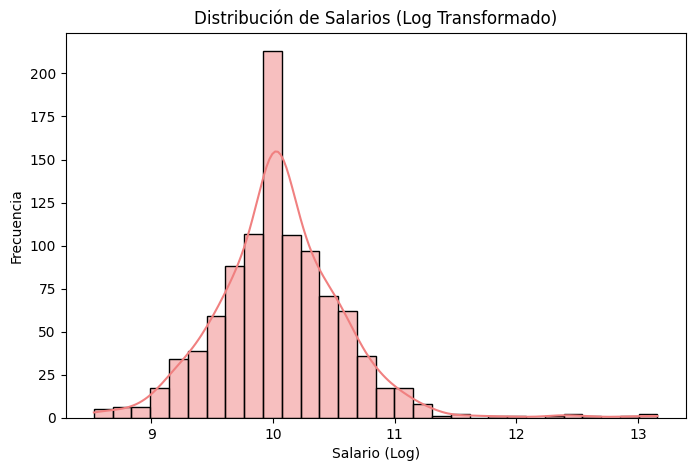

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribucion de Salarios original
plt.figure(figsize=(8, 5))
sns.histplot(datos['salario'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Salarios (Original)')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')

# Distribución de Salario transformado (log)
plt.figure(figsize=(8, 5))
sns.histplot(datos['salario_log'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución de Salarios (Log Transformado)')
plt.xlabel('Salario (Log)')
plt.ylabel('Frecuencia')
plt.show()

## Week 4 - ETL Básico

Diseño conceptual de pipeline ETL para un escenario empresarial


Escenario: Una cadena de tiendas minoristas quiere integrar datos de:

- Sistema de punto de venta (ventas por tienda, producto, hora)
- Sistema de inventario (stock por producto y ubicación)
- CRM (información de clientes y segmentación)
- Sitio web (comportamiento online de clientes)

Tareas de diseño:

- Identificar fuentes de datos:
- Base de datos SQL del POS
- API REST del sistema de inventario
- Archivos CSV exportados del CRM
- Logs del servidor web (JSON)

Diseñar esquema destino:
```
-- Tabla unificada de hechos de ventas
CREATE TABLE ventas_consolidadas (
    id_venta INTEGER PRIMARY KEY,
    fecha_venta DATE,
    id_tienda INTEGER,
    id_cliente INTEGER,
    id_producto INTEGER,
    cantidad INTEGER,
    precio_unitario DECIMAL(10,2),
    total_venta DECIMAL(10,2),
    canal_venta VARCHAR(20), -- 'online', 'tienda'
    segmento_cliente VARCHAR(20)
);
```



Planificar transformaciones:
- Convertir timestamps a fechas consistentes
- Calcular totales de venta (cantidad × precio)
- Enriquecer con información de cliente (segmento)
- Normalizar códigos de producto entre sistemas
- Detectar y manejar ventas duplicadas

Definir frecuencia y estrategia:

- Ventas del POS: carga incremental cada hora
- Inventario: actualización completa diaria
- CRM: actualización semanal
- Web analytics: carga batch diaria



Extracción desde múltiples fuentes heterogéneas

Crear datos de ejemplo en diferentes formatos:

In [1]:
import pandas as pd
import sqlite3
import json

# Crear CSV
ventas_csv = pd.DataFrame({
    'id_venta': range(1, 6),
    'producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Audífonos'],
    'precio': [1200, 25, 80, 300, 150]
})
ventas_csv.to_csv('ventas.csv', index=False)

# Crear Excel con múltiples hojas
clientes_df = pd.DataFrame({
    'id_cliente': [1, 2, 3],
    'nombre': ['Ana', 'Carlos', 'María'],
    'ciudad': ['Madrid', 'Barcelona', 'Valencia']
})

with pd.ExcelWriter('datos.xlsx') as writer:
    ventas_csv.to_excel(writer, sheet_name='Ventas', index=False)
    clientes_df.to_excel(writer, sheet_name='Clientes', index=False)

# Crear JSON
productos_json = [
    {'id': 101, 'nombre': 'Laptop', 'categoria': 'Electrónica'},
    {'id': 102, 'nombre': 'Mouse', 'categoria': 'Accesorios'}
]
with open('productos.json', 'w') as f:
    json.dump(productos_json, f)

# Crear base de datos SQLite
conn = sqlite3.connect('ventas.db')
pedidos_df = pd.DataFrame({
    'id_pedido': [1, 2, 3],
    'id_cliente': [1, 2, 1],
    'fecha': ['2024-01-15', '2024-01-16', '2024-01-17'],
    'total': [1225, 25, 380]
})
pedidos_df.to_sql('pedidos', conn, index=False, if_exists='replace')
conn.close()

Extraer desde cada fuente:

In [2]:
# Desde CSV
df_csv = pd.read_csv('ventas.csv')
print("Desde CSV:")
print(df_csv.head())

# Desde Excel (hoja específica)
df_excel_ventas = pd.read_excel('datos.xlsx', sheet_name='Ventas')
df_excel_clientes = pd.read_excel('datos.xlsx', sheet_name='Clientes')
print("\nDesde Excel - Ventas:")
print(df_excel_ventas.head())

# Desde JSON
df_json = pd.read_json('productos.json')
print("\nDesde JSON:")
print(df_json)

# Desde SQLite
conn = sqlite3.connect('ventas.db')
df_sql = pd.read_sql('SELECT * FROM pedidos', conn)
conn.close()
print("\nDesde SQLite:")
print(df_sql)

Desde CSV:
   id_venta   producto  precio
0         1     Laptop    1200
1         2      Mouse      25
2         3    Teclado      80
3         4    Monitor     300
4         5  Audífonos     150

Desde Excel - Ventas:
   id_venta   producto  precio
0         1     Laptop    1200
1         2      Mouse      25
2         3    Teclado      80
3         4    Monitor     300
4         5  Audífonos     150

Desde JSON:
    id  nombre    categoria
0  101  Laptop  Electrónica
1  102   Mouse   Accesorios

Desde SQLite:
   id_pedido  id_cliente       fecha  total
0          1           1  2024-01-15   1225
1          2           2  2024-01-16     25
2          3           1  2024-01-17    380


API simulada (usando requests si está disponible):

In [3]:
# Simular API response
api_response = {
    'status': 'success',
    'data': [
        {'id': 201, 'producto': 'Webcam', 'stock': 15},
        {'id': 202, 'producto': 'Micrófono', 'stock': 8}
    ]
}

# Simular consumo de API
import json
df_api = pd.DataFrame(api_response['data'])
print("\nDesde API simulada:")
print(df_api)


Desde API simulada:
    id   producto  stock
0  201     Webcam     15
1  202  Micrófono      8


Pipeline de transformación completo con validaciones

Crear dataset con datos que requieren transformación:

In [4]:
import pandas as pd
import numpy as np

# Crear datos con problemas realistas
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'id_cliente': range(1, n+1),
    'edad': np.random.normal(35, 15, n).clip(18, 80).astype(int),
    'ingresos': np.random.lognormal(10, 0.8, n),
    'gastos_mensuales': np.random.normal(2000, 500, n).clip(500, 10000),
    'categoria_cliente': np.random.choice(['A', 'B', 'C', 'D'], n),
    'fecha_registro': pd.date_range('2020-01-01', periods=n, freq='D')[:n],
    'email': [f'cliente{i}@ejemplo.com' for i in range(1, n+1)],
    'telefono': [f'({np.random.randint(100, 999)}){np.random.randint(100, 999)}-{np.random.randint(1000, 9999)}' for _ in range(n)]
})

# Introducir algunos errores intencionalmente
error_indices = np.random.choice(n, 50, replace=False)
df.loc[error_indices[:20], 'edad'] = np.random.choice([-5, 150, np.nan], 20)  # Edades inválidas
df.loc[error_indices[20:35], 'ingresos'] = -1000  # Ingresos negativos
df.loc[error_indices[35:], 'gastos_mensuales'] = df.loc[error_indices[35:], 'ingresos'] * 2  # Gastos > ingresos

Aplicar validaciones y correcciones:

In [5]:
# Validar y corregir edades
df['edad_valida'] = df['edad'].apply(lambda x: True if 18 <= x <= 80 else False)
df.loc[~df['edad_valida'], 'edad'] = np.nan  # Marcar inválidas como NaN

# Validar ingresos (no negativos)
df.loc[df['ingresos'] < 0, 'ingresos'] = np.nan

# Validar gastos vs ingresos
df['ratio_gasto_ingreso'] = df['gastos_mensuales'] / df['ingresos']
df.loc[df['ratio_gasto_ingreso'] > 1, 'gastos_mensuales'] = df.loc[df['ratio_gasto_ingreso'] > 1, 'ingresos'] * 0.8

Crear transformaciones y enriquecimientos:

In [6]:
# Categorizar por edad
df['grupo_edad'] = pd.cut(df['edad'],
                        bins=[18, 25, 35, 50, 80],
                        labels=['Joven', 'Adulto_Joven', 'Adulto', 'Senior'])

# Calcular capacidad de ahorro
df['capacidad_ahorro'] = df['ingresos'] - df['gastos_mensuales']
df['ratio_ahorro'] = df['capacidad_ahorro'] / df['ingresos']

# Clasificar capacidad financiera
df['clasificacion_financiera'] = np.where(df['ratio_ahorro'] > 0.3, 'Ahorra_Mucho',
                                         np.where(df['ratio_ahorro'] > 0.1, 'Ahorra_Poco',
                                                 np.where(df['ratio_ahorro'] > 0, 'Equilibra', 'Deficit')))

# Extraer información del teléfono
df['codigo_area'] = df['telefono'].str.extract(r'\((\d{3})\)')

# Calcular antigüedad
df['antiguedad_dias'] = (pd.Timestamp.now() - df['fecha_registro']).dt.days
df['antiguedad_meses'] = df['antiguedad_dias'] // 30

Crear métricas agregadas por categoría:

In [7]:
# Métricas por grupo de edad
metricas_edad = df.groupby('grupo_edad').agg({
    'ingresos': ['mean', 'median', 'std'],
    'capacidad_ahorro': 'mean',
    'ratio_ahorro': 'mean'
}).round(2)

print("Métricas por grupo de edad:")
print(metricas_edad)

# Resumen de validaciones
resumen_validacion = {
    'total_registros': len(df),
    'edades_invalidas': (~df['edad_valida']).sum(),
    'ingresos_negativos_corregidos': (df['ingresos'].isna()).sum(),
    'registros_procesados': len(df)
}

print("\nResumen de validación:")
for clave, valor in resumen_validacion.items():
    print(f"{clave}: {valor}")

Métricas por grupo de edad:
              ingresos                     capacidad_ahorro ratio_ahorro
                  mean    median       std             mean         mean
grupo_edad                                                              
Joven         32954.67  26454.09  25962.62         30926.97         0.88
Adulto_Joven  31465.15  23640.71  25554.76         29336.67         0.87
Adulto        31504.19  21448.63  32238.73         29145.95         0.87
Senior        31016.96  22286.82  26921.09         28876.55         0.88

Resumen de validación:
total_registros: 1000
edades_invalidas: 20
ingresos_negativos_corregidos: 15
registros_procesados: 1000


/tmp/ipython-input-2255973119.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metricas_edad = df.groupby('grupo_edad').agg({
